# Bayesian Inference on Experimental ALD Data

This file was made as an example of how BAPAO works on real experimental data. \
Each step will take a new user through how to use BAPAO for their own usecases.

## Imports
Get all functions and dependencies required. Requires BAPAO to be installed already, most commonly done by:
```bash
cd BAPAO
pip install -e .
```
For more help with instalation see the README.md

In [1]:
%matplotlib inline
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from BAPAO import (
    ALDType,
    FitModule,
    ModelType,
    build_surrogate,
    load_experimental_profile_csv,
    make_config,
    plot_chain_traces,
    plot_double_exponential_fit,
    plot_pairwise_posteriors,
    plot_prediction_comparison,
    PhysicsModel,
    GaussianPrior,
    run_mcmc,
    single_profile_observation,
)

# set path for output and data
REPO_ROOT = Path.cwd().resolve().parents[0]
SRC_ROOT = REPO_ROOT / "src"
sys.path.append(str(SRC_ROOT))

## Set Run Settings
Here you can decide what parameters should be infered, what the noise over the observations was and MCMC settings.

In [2]:
PARAMETERS = ["s0", "k"]

# Parameter bounds for inference (only needed for parameters you're inferring)
PARAM_BOUNDS = {
    "s0": (1e-6, 1e-1),
    "k": (1e-2, 1e1),
}

# Data generation parameters
OBSERVATION_NOISE = 0.03  # Standard deviation of measurement noise

# MCMC parameters
NWALKERS = 32  # Number of ensemble walkers
NSTEPS = 5000  # Number of MCMC steps per walker

# Output directory for plots and results
OUTPUT_DIR = REPO_ROOT / "examples" / "example_output" / "thermal_experimental"
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print("Output directory:", OUTPUT_DIR)

if not PARAMETERS:
    raise ValueError("PARAMETERS list cannot be empty")

Output directory: C:\Users\fklab\Documents\Git_Repos\BAPAO\examples\example_output\thermal_experimental


## Load Data
Load the experimental data. Here we use the helper function `load_experimetnal_profile_csv` to get our parameters for us. Any .csv file with the columns "Distance" for xi and "Normalized Signal" for theta will work. \
If you want to load data yourself that works to, just make sure that both the depth and thickness are normalized to 1 before adding them to `xi_obs` and `theta_obs`.

In [3]:
PATH = REPO_ROOT / "examples" / "example_data" / "TMA_Puurunen_1.csv" # choose dataset by changing number to either 1, 2 or 3

# any .csv file with the columns "Distance" for xi and "Normalized Signal" for theta will work 
dataset_dict = load_experimental_profile_csv(PATH)

# observed data
xi_obs = dataset_dict["xi_obs"]
theta_obs = dataset_dict["theta_obs"]
dataset_name = dataset_dict["dataset_name"]

# build observations object
observations = [
    single_profile_observation( # if you have multiple datasets, you can add them here as additional observations for MCMC to use
        xi_obs,
        theta_obs,
        OBSERVATION_NOISE,
    )
]

## Build config and create surrogate model
This is mandatory setup you can mostly ignore. It builds the surrogate model which MCMC needs to de the evaluation.

In [4]:
# Filter bounds to only include parameters we're inferring
bounds = {p: PARAM_BOUNDS[p] for p in PARAMETERS}

# Create config with specified parameters
config = make_config(
    names=PARAMETERS,
    bounds=bounds,
)

print(f"Configuration: {len(observations)} observation(s), {len(PARAMETERS)} parameter(s)")
print(f"Parameters to infer: {config['names']}")
print()

# Build neural network surrogate model
model = build_surrogate(config["names"])

Configuration: 1 observation(s), 2 parameter(s)
Parameters to infer: ['s0', 'k']



## Do the double exponential fit on data
Here we use the double exponential function
$$ \theta (\xi) = 1 - \exp(-b \exp(-c\xi)),$$
as was derived in the original paper, where $b = \frac{3}{4}AR^2 s_0 k$ determines the penetration depth and $c~=~AR\sqrt{\frac{3}{4}(0.79\,s_0 + r)}$ is the slope width.

The functions below fit this function and plot the fitted value over the profile.

Fitted x50: 0.21292585087712004, B: 56.61521389682046

Parameter estimation results from Double exponential fit:
{'sticking_prob': 0.005409759400139632, 'dim_dose': 29.372293902748687}


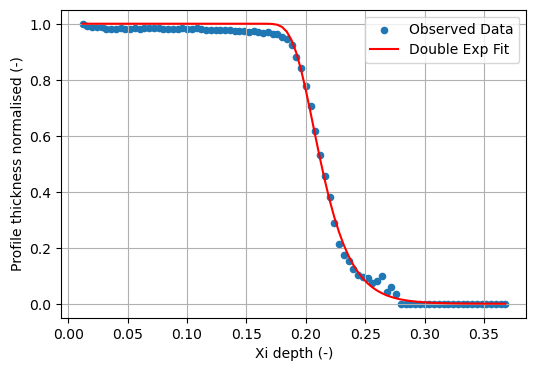

In [5]:
fitter = FitModule()
popt, results = fitter.fit_profile(
    xi_obs, theta_obs, model_type=ModelType.DOUBLE_EXP_STABLE, ald_type=ALDType.THERMAL
)

s0_from_double_exp = results["sticking_prob"]
print("\nParameter estimation results from Double exponential fit:")
print(results)

plot_double_exponential_fit(xi_obs,
                            theta_obs,
                            popt,
                            save_path = OUTPUT_DIR / "0_double_exponential_fit.png"
                            )

## Building a prior based on the double exponential result
The double exponential fit is on its own a good way to determine $s_0$, but if uncertanties or a good estimation of $k$ are required we still need to do MCMC.

Below we encode our prior knowledge i.e. the double exponential fit, for Bayesian Inference. Note that we can also encode other prior knowledge this way, like literature values or $s_0$ estimates from different experiments. This will make MCMC consider our knowledge, which generally leads to better results and lower uncertainties.

In [6]:
prior = GaussianPrior(
    means={
        "s0": s0_from_double_exp,
    },
    sigmas={
        "s0": 0.2 * s0_from_double_exp,   # choose width appropriately
    },
)

## MCMC inference
Below we run the MCMC sampler using the settings defined earlier. On consumer hardware, this may take somewhere between 2 and 5 minutes. If tqdm is installed a progressbar will tell you how long it still takes.

After MCMC is finished a print reporting the Maximum a posterior (MAP) and Maximum Likelihood Estimator (MLE) should be reported.
MLE reports the maximum likelihood, and thus does not take the prior into account.
MAP reports the maximum of the sum of the likelihood and the prior.

The difference between the MAP and MLE can thus give a rough idea how much the prior moved the prediction. Generally stick to the MAP as the correct estimation. Note that for Uniform priors the MAP and MLE should be equal.

In [7]:
print(f"\nRunning MCMC with {NWALKERS} walkers and {NSTEPS} steps...")
results = run_mcmc(
    model=model,
    config=config,
    observations=observations,
    nwalkers=NWALKERS,
    nsteps=NSTEPS,
    prior=prior
)

print("\n" + "=" * 60)
print("MCMC RESULTS")
print("=" * 60)
print(f"Parameters inferred: {config['names']}")
print("MAP (Maximum A Posteriori):", results["map"])

# Convert MAP from array to dict
map_array = results["map"]
if isinstance(map_array, np.ndarray):
    map_dict = {name: float(val) for name, val in zip(config["names"], map_array)}
else:
    map_dict = results.get("map", {})


print("MLE (Maximum Likelihood Estimate):", results["mle"])
print("=" * 60 + "\n")



Running MCMC with 32 walkers and 5000 steps...


100%|██████████| 5000/5000 [02:58<00:00, 28.01it/s]



MCMC RESULTS
Parameters inferred: ['s0', 'k']
MAP (Maximum A Posteriori): [0.00517504 0.02385154]
MLE (Maximum Likelihood Estimate): [0.00513836 0.02385301]



# Plotting functions

## Posterior distribution plot
This plot shows the joint posterior of the estimated values of $\log s_0$ and $\log k$. If slightly eliptical, they are correlated. The orange MAP dot gives the estimated value and the width of the Gaussian distribuitons gives the uncertainties.

For certain problems the plot will be very zoomed in into a nice eliptical shape. For others it might be more zoomed out with multiple peaks, of varying height. If multiple peaks are equally possible we have a poorly constrained problem and finding the real parameters might not be possible. The upside of MCMC is that it will always show this.

C:\Users\fklab\Documents\Git_Repos\BAPAO\src\BAPAO\plotting.py:739: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


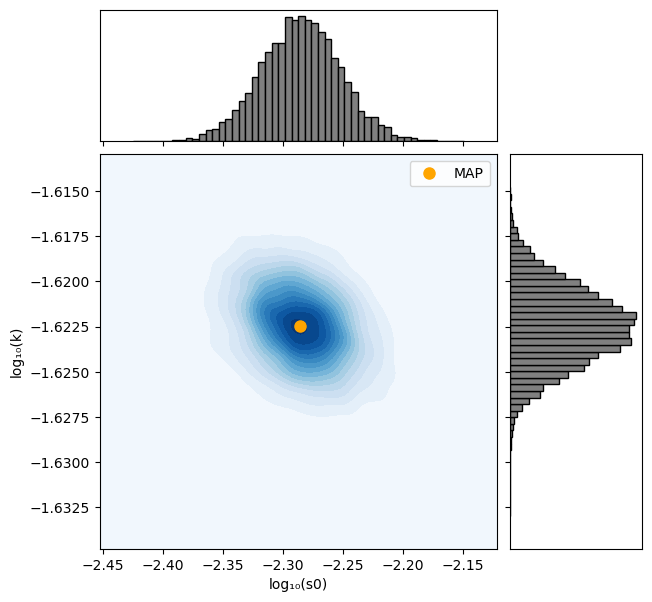

In [8]:
plot_pairwise_posteriors(
    results=results,
    save_path=OUTPUT_DIR / "01_posteriors.png",
)

## Chain traces plot
The plot below are the chain traces of the MCMC algorithm. MCMC utilises independent "walkers" that are initialised in the parameter space and "walk" in the most likely direction. For well defined MCMC problems we expect all walkers to end up in the same place. If any walkers end up somehwere else, this plot shows it. If a run didnt converge, it likely needs more steps or a good prior.

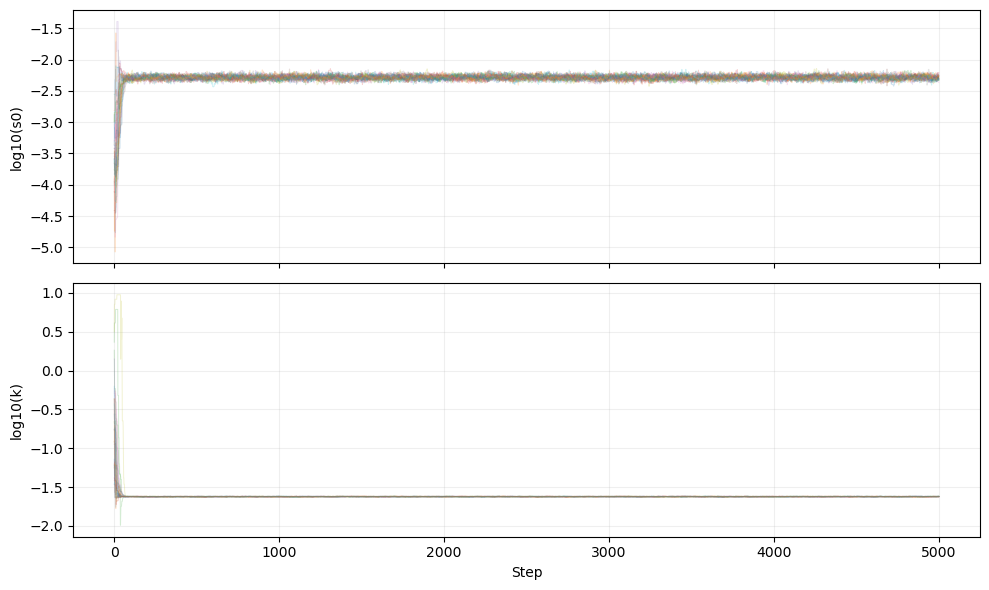

In [9]:
plot_chain_traces(
    results=results,
    save_path=OUTPUT_DIR / "02_chain_traces.png",
)

## Prediction value compared to the experimental data
If we plug the predicted parameters back into the physics model, we can visually inspect the prediction compared to the profile, this is done below.

This is important to do as we use a surrogate model, as their predictions can slightly deviate from the real physics prediction.

If the plot is right this doesnt neccecarly mean this is a good fit (if multiple parameters give the same outcome, then we still havent identified the right one), but if this plot is off we know for sure something is wrong.

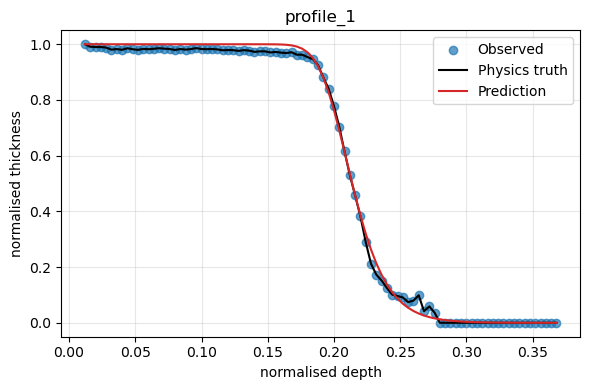

In [10]:
phy_model = PhysicsModel(AR = 1000)

plot_prediction_comparison(
    model=phy_model,
    observations=observations,
    params=map_dict,
    save_path=OUTPUT_DIR / "03_MCMC_prediction_comparison.png",
)

In [11]:
results_file = OUTPUT_DIR / "mcmc_results.txt"
with open(results_file, "w") as f:
    f.write(f"Parameters: {', '.join(config['names'])}\n")
    f.write(f"Number of Observations: {len(observations)}\n")
    f.write("\nTrue Parameters:\n")
    f.write("\nEstimated Parameters (MAP):\n")
    for name, val in map_dict.items():
        f.write(f"  {name}: {val:.6e}\n")
    f.write("\nMCMC Settings:\n")
    f.write(f"  Walkers: {NWALKERS}\n")
    f.write(f"  Steps: {NSTEPS}\n")
    f.write(f"  Observation Noise: {OBSERVATION_NOISE}\n")

print(f"Results summary saved to: {results_file}\n")

Results summary saved to: C:\Users\fklab\Documents\Git_Repos\BAPAO\examples\example_output\thermal_experimental\mcmc_results.txt

